<a href="https://colab.research.google.com/github/szczpanski/dev/blob/main/rnn_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sobre o projeto:

Se trata de um modelo de aprendizagem suprvisionado de classificação binária envolvendo dados relativos ao Câncer de Mama. Os dados foram extraídos do site do Kaggle.


---


Convenções de reprodutibilidade:

Todas as bibliotecas se encontram no arquivo 📄requirements.txt

Para mais informções, consulte nosso README

## Parte 01. Importar os pacotes



---



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, classification_report
)
from sklearn.dummy import DummyClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import AUC

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import uniform, randint


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Parte 02. Baixar e ler os dados

---



O arquivo será baixado diretamente do repositório do Kaggle. Caso a estrutura de pastas não exista, o algoritmo irá construí-la.

In [4]:
!pip install -q kaggle
!rm -rf kaggle.json
from google.colab import files

files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"felipeinfnet","key":"1e14ff74d716fb2b0bd70f27fa9af330"}'}

In [5]:
!rm -rf .kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download --force -d wasiqaliyasir/breast-cancer-dataset
!unzip -o breast-cancer-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset
License(s): apache-2.0
  0% 0.00/48.7k [00:00<?, ?B/s]
100% 48.7k/48.7k [00:00<00:00, 125MB/s]
Archive:  breast-cancer-dataset.zip
  inflating: Breast_cancer_dataset.csv  


In [7]:
# "breast_cancer.csv"
df = pd.read_csv("Breast_cancer_dataset.csv")

## Parte 03. Análise exploratória


---





In [8]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 569 linhas e 33 colunas.


3.1. Visão geral do dataset

In [9]:
def check(df):
    l = []
    colunas = df.columns
    for col in colunas:
        dtypes = df[col].dtypes
        nunique = df[col].nunique()
        sum_null = df[col].isnull().sum()

        moda = df[col].mode().iloc[0] if not df[col].mode().empty else "Não se aplica"
        moda_freq = df[col].value_counts().iloc[0] if not df[col].value_counts().empty else "Não se aplica"

        if np.issubdtype(dtypes, np.number):
            status = df.describe(include='all').T
            media = status.loc[col, 'mean']
            std = status.loc[col, 'std']
            min_val = status.loc[col, 'min']
            quar1 = status.loc[col, '25%']
            mediana = df[col].median()
            quar3 = status.loc[col, '75%']
            max_val = status.loc[col, 'max']
        else:
            status = "Não se aplica"
            media = "Não se aplica"
            std = "Não se aplica"
            min_val = "Não se aplica"
            quar1 = "Não se aplica"
            mediana = "Não se aplica"
            quar3 = "Não se aplica"
            max_val = "Não se aplica"

        l.append([col, dtypes, nunique, sum_null, media, std, min_val, quar1, mediana, quar3, max_val, moda, moda_freq])

    df_check = pd.DataFrame(l, columns=[
        'coluna','tipo','únicos','null_soma','media','desvio',
        'minimo','25%','mediana','75%','maximo','moda','frequência_moda'
    ])
    return df_check

In [10]:
# Análise geral dos dados
check(df)

,coluna,tipo,únicos,null_soma,media,desvio,minimo,25%,mediana,75%,maximo,moda,frequência_moda
0,id,int64,569,0,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0,8670,1
1,diagnosis,object,2,0,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,B,357
2,radius_mean,float64,456,0,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11,12.34,4
3,texture_mean,float64,479,0,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28,14.93,3
4,perimeter_mean,float64,522,0,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5,82.61,3
5,area_mean,float64,539,0,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0,512.2,3
6,smoothness_mean,float64,474,0,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634,0.1007,5
7,compactness_mean,float64,537,0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454,0.1147,3
8,concavity_mean,float64,537,0,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268,0.0,13
9,concave points_mean,float64,542,0,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012,0.0,13


In [11]:
# Análise dos tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

É possível verificar que o dataset original possui 33 colunas, das quais uma ('Unamed: 32') possui apenas dados nulos.

Além disso, com execeção da coluna 'diagnosis' (que é uma coluna categórica), as demais colunas são colunas numéricas, com informações sobre cada paciente.

### 3.2. Análise da distribuição dos dados

### 3.3. Pairplot - Análise de Relacionamentos entre Variáveis

O **Pairplot** (ou scatterplot matrix) é uma ferramenta fundamental na análise exploratória de dados (EDA). Este gráfico mostra, para cada par de variáveis numéricas, como elas se relacionam, além da distribuição individual em forma de histograma/densidade na diagonal.

**Para que serve**:

* **Exploração de dados (EDA)**: Antes de treinar uma rede neural (ou qualquer modelo de machine learning), é essencial entender como os dados estão distribuídos, se existem correlações fortes entre variáveis e se há separabilidade entre classes.

* **Redução de dimensionalidade** / seleção de features: O pairplot ajuda a identificar variáveis altamente correlacionadas (como radius_mean, perimeter_mean e area_mean), que podem ser redundantes. Isso é útil porque redes neurais podem sofrer com dados redundantes ou multicolinearidade.

* **Identificação de padrões de separação**: Você pode ver se as classes se separam visualmente em determinados pares de features. Isso dá uma intuição de quais variáveis carregam mais poder discriminativo.

**Quando usar em relação a uma rede neural**:

* **Antes do treinamento**: Para inspecionar os dados, escolher features relevantes e entender possíveis ajustes de pré-processamento (normalização, remoção de redundâncias).

* **Não durante o treinamento**: O pairplot é puramente exploratório; não entra como input em uma rede neural. A rede usará os valores numéricos das features (normalizados ou padronizados), não o gráfico em si.

**Fluxo típico**:

1. EDA com pairplot → 2. Pré-processamento (scaling, seleção de features, balanceamento de classes) →
2. Treino da rede neural (ou outro modelo).

Este gráfico é como o 'raio-X' inicial dos dados, antes de colocar a rede para aprender.

In [12]:
# EDA
_ = check(df)

df_pairplot = df.copy()
label_encoder = LabelEncoder()
df_pairplot['diagnosis_encoded'] = label_encoder.fit_transform(df_pairplot['diagnosis'])

features_for_pairplot = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','diagnosis_encoded']
df_subset = df_pairplot[features_for_pairplot]

print(f"Variáveis selecionadas para o Pairplot: {features_for_pairplot[:-1]}")
print(f"Classes: 0 = Benigno ({sum(df_pairplot['diagnosis_encoded']==0)} casos), 1 = Maligno ({sum(df_pairplot['diagnosis_encoded']==1)} casos)")

Variáveis selecionadas para o Pairplot: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
Classes: 0 = Benigno (357 casos), 1 = Maligno (212 casos)


<Figure size 1500x1200 with 0 Axes>

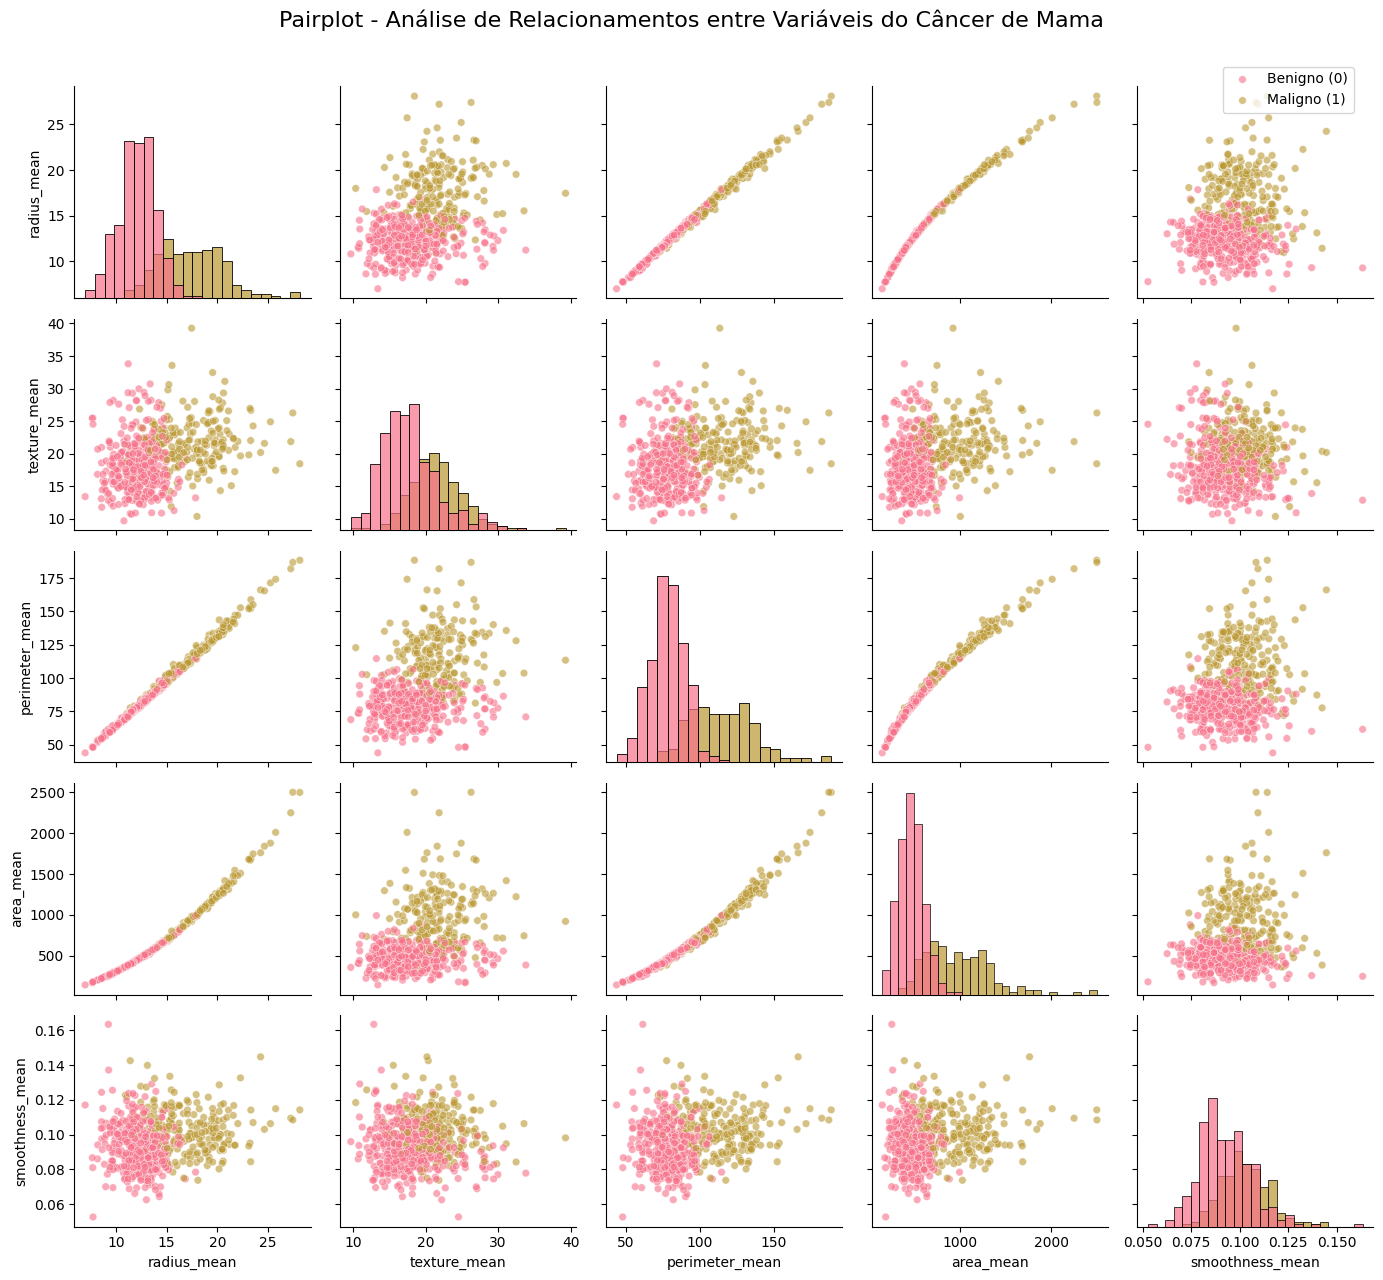

In [13]:
# Configurar o estilo do seaborn
plt.style.use('default')
sns.set_palette("husl")

# Criar o pairplot
fig = plt.figure(figsize=(15, 12))

# Pairplot com separação por classe
pairplot = sns.pairplot(
    df_subset,
    hue='diagnosis_encoded',
    diag_kind='hist',
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kws={'alpha': 0.7}
)

# Personalizar o gráfico
pairplot.fig.suptitle('Pairplot - Análise de Relacionamentos entre Variáveis do Câncer de Mama',
                      fontsize=16, y=1.02)

# Ajustar as legendas
handles = pairplot._legend_data.values()
labels = ['Benigno (0)', 'Maligno (1)']
pairplot.fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Remover a legenda original
pairplot._legend.remove()

plt.tight_layout()
plt.show()

**Análise do Pairplot**:

1. **Correlações Fortes**: Observamos correlações muito fortes entre radius_mean, perimeter_mean e area_mean, o que é esperado geometricamente (raio, perímetro e área estão matematicamente relacionados).

2. **Separabilidade das Classes**:

* Tumores malignos (classe 1) tendem a ter valores maiores de raio, perímetro e área
* Existe uma boa separação visual entre as classes em várias combinações de variáveis
* A textura também mostra alguma capacidade discriminativa

3. **Distribuições**:

* As distribuições na diagonal mostram que algumas variáveis podem se beneficiar de normalização
* Há evidência de que as classes têm distribuições diferentes para a maioria das variáveis

4. **Implicações para a Rede Neural**:

* A forte correlação entre algumas variáveis sugere que podemos considerar redução de dimensionalidade
* A boa separabilidade visual indica que uma rede neural deve conseguir aprender padrões discriminativos
* A necessidade de normalização é evidente devido às diferentes escalas das variáveis.

É possível verificar que o dataset original possui 33 colunas, das quais uma ('Unamed: 32') possui apenas dados nulos.

Além disso, com execeção da coluna 'diagnosis' (que é uma coluna categórica), as demais colunas são colunas numéricas, com informações sobre cada paciente.

### 3.2. Análise da distribuição dos dados

In [14]:
# Análise da distribuição da variável target
print(f"Distribuição da variável target:")

print(df['diagnosis'].value_counts())

print(f"\nPercentual da distribuição da variável target:")

print(df['diagnosis'].value_counts(normalize=True) * 100)

Distribuição da variável target:
diagnosis
B    357
M    212
Name: count, dtype: int64

Percentual da distribuição da variável target:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


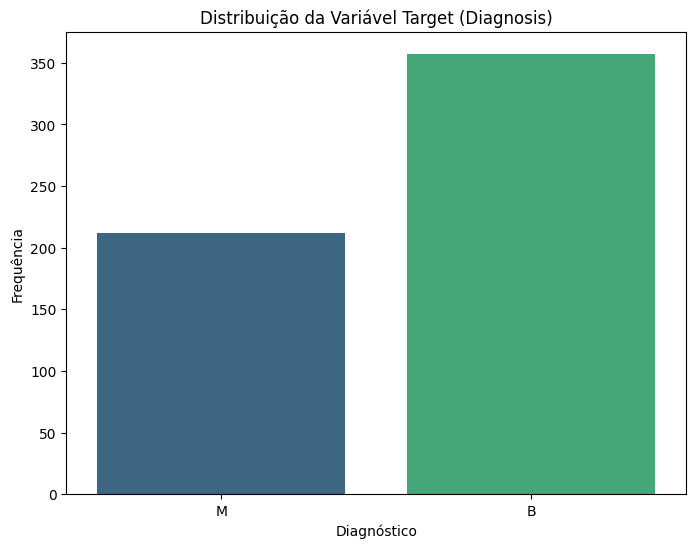

In [15]:
# Visualização da distribuição da variável target
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='diagnosis', palette='viridis')
plt.title('Distribuição da Variável Target (Diagnosis)')
plt.xlabel('Diagnóstico')
plt.ylabel('Frequência')
plt.show()

### Parte 04. Tratamento dos dados (exclusão da coluna nula)

---



In [16]:
# Removendo a coluna com valores nulos
df = df.drop('Unnamed: 32', axis=1)
print(f"Novo shape do dataset: {df.shape}")

Novo shape do dataset: (569, 32)


### Parte 05. Verificando a correlação entre as colunas

---



In [17]:
# Codificando a variável target para análise de correlação
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])
print(f"Mapeamento: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Mapeamento: {'B': 0, 'M': 1}


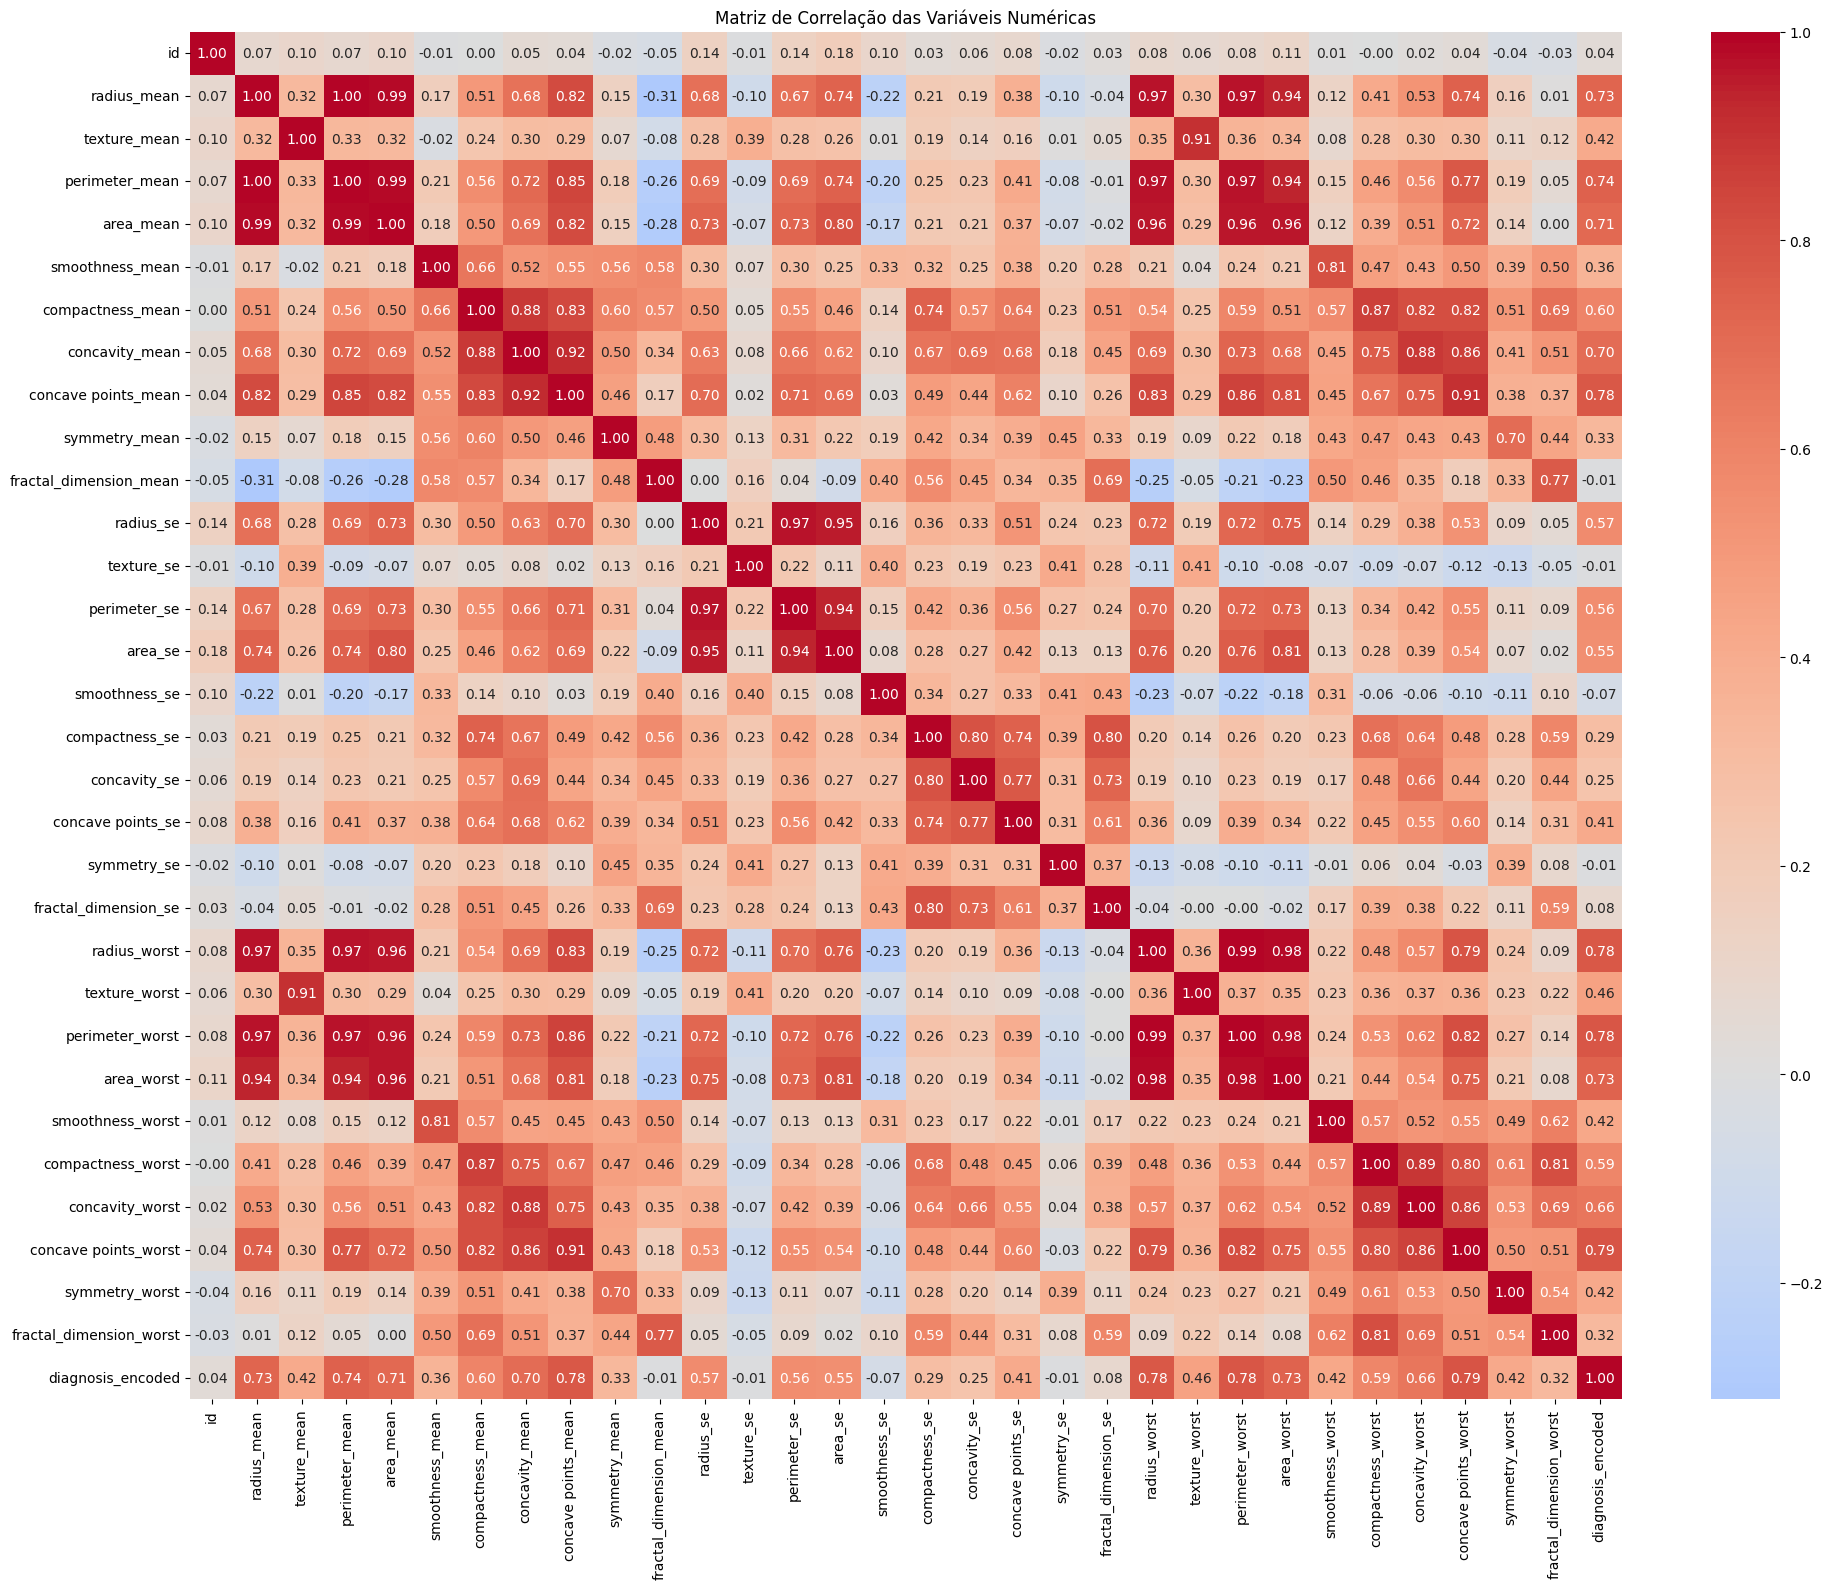

In [18]:
# Matriz de correlação
plt.figure(figsize=(20, 16))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.tight_layout()
plt.show()

### Parte 06. Separar as features utilizadas

---



In [19]:
# Separando features e target
X = df.drop(['id', 'diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

print(f"Shape das features (X): {X.shape}")
print(f"Shape do target (y): {y.shape}")

Shape das features (X): (569, 30)
Shape do target (y): (569,)


### Parte 07. Normalização com o Standard Scaler

---



In [20]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train: (455, 30)
Shape X_test: (114, 30)
Shape y_train: (455,)
Shape y_test: (114,)


In [21]:
# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Média antes da normalização: {X_train.mean().mean():.4f}")
print(f"Desvio padrão antes: {X_train.std().mean():.4f}")
print(f"Média após normalização: {X_train_scaled.mean():.4f}")
print(f"Desvio padrão após: {X_train_scaled.std():.4f}")

Média antes da normalização: 62.4573
Desvio padrão antes: 35.7565
Média após normalização: 0.0000
Desvio padrão após: 1.0000


### Parte 08. Modelos baseline

---



8.1. Criando um dumb model (baseline) prevendo tudo como a classe majoritária para validações futuras

In [22]:
# Baseline trivial (Dummy)
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print("=== DUMB MODEL (Baseline) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}")

=== DUMB MODEL (Baseline) ===
Accuracy:  0.6316
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


8.2. Criando um baseline de Keras

In [31]:
# Modelo baseline com Keras
def create_baseline_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Criando e treinando o modelo
baseline_model = create_baseline_model()

history_baseline = baseline_model.fit(X_train_scaled, y_train,
                                      validation_split=0.2,
                                      epochs=100,
                                      batch_size=32,
                                      verbose=1,
                                      callbacks=[early_stop])

# Predições
y_pred_baseline_prob = baseline_model.predict(X_test_scaled)
y_pred_baseline = (y_pred_baseline_prob > 0.5).astype(int).flatten()

# Métricas
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline):.4f}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5763 - loss: 0.6500 - val_accuracy: 0.8901 - val_loss: 0.4190
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9329 - loss: 0.3476 - val_accuracy: 0.9231 - val_loss: 0.2569
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9563 - loss: 0.2112 - val_accuracy: 0.9341 - val_loss: 0.1901
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9625 - loss: 0.1479 - val_accuracy: 0.9560 - val_loss: 0.1595
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9665 - loss: 0.1145 - val_accuracy: 0.9560 - val_loss: 0.1423
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9710 - loss: 0.0939 - val_accuracy: 0.9560 - val_loss: 0.1304
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9710 - loss: 0.0796 - val_accuracy: 0.9560 - val_loss: 0.1210
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9751 - loss: 0.0691 - val_accuracy: 0.9670 -

### Parte 09. Grid search

---



In [33]:
# Função para criar o modelo com uma única camada oculta
def create_model(neurons=6):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Variáveis para rastrear o melhor modelo
best_f1 = 0
best_neurons = None
best_model = None

# Teste para uma camada oculta com 2 a 10 neurônios
for n in range(2, 11, 2):  # 2, 4, 6, 8, 10
    print(f"\n Testando modelo com {n} neurônios")

    model = create_model(neurons=n)
    history = model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    # Predições
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Métrica principal
    f1 = f1_score(y_test, y_pred)
    print(f"F1-Score: {f1:.4f}")

    # Melhor modelo
    if f1 > best_f1:
        best_f1 = f1
        best_neurons = n
        best_model = model

# Resultados finais
print(f"Camada oculta: {best_neurons} neurônios")
print(f"F1-Score: {best_f1:.4f}")

# Avaliação do melhor modelo
y_pred_best = (best_model.predict(X_test_scaled) > 0.5).astype(int).flatten()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")



 Testando modelo com 2 neurônios
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
F1-Score: 0.9383

 Testando modelo com 4 neurônios
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
F1-Score: 0.9880

 Testando modelo com 6 neurônios
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
F1-Score: 0.9524

 Testando modelo com 8 neurônios
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
F1-Score: 0.9756

 Testando modelo com 10 neurônios
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
F1-Score: 0.9756
Camada oculta: 4 neurônios
F1-Score: 0.9880
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9762
F1-Score:  0.9880


### Parte 10. Comparação dos modelos

---



In [42]:
models_comparison = pd.DataFrame({
    'Modelo': ['Dumb Classifier', 'Keras Baseline', 'Grid Search'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dummy, zero_division=0),
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dummy, zero_division=0),
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dummy, zero_division=0),
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_best)
    ]
})

print("=== COMPARAÇÃO DOS MODELOS ===")
print(models_comparison.round(4))


=== COMPARAÇÃO DOS MODELOS ===
            Modelo  Accuracy  Precision  Recall  F1-Score
0  Dumb Classifier    0.6316        0.0  0.0000    0.0000
1   Keras Baseline    0.9825        1.0  0.9524    0.9756
2      Grid Search    0.9912        1.0  0.9762    0.9880


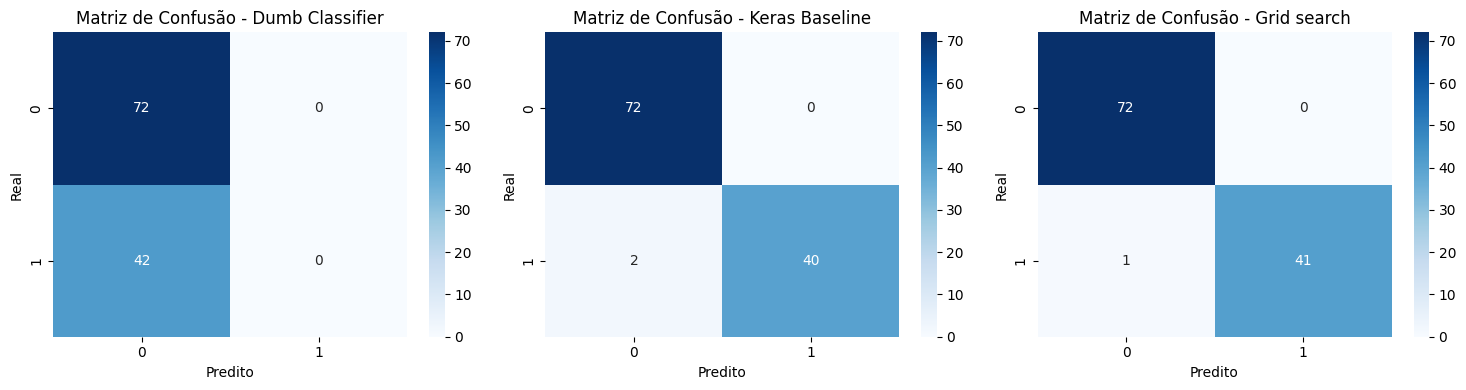

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_preds = [y_pred_dummy, y_pred_baseline, y_pred_best]
model_names = ['Dumb Classifier', 'Keras Baseline', 'Grid search']

for i, (pred, name) in enumerate(zip(models_preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz de Confusão - {name}')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()


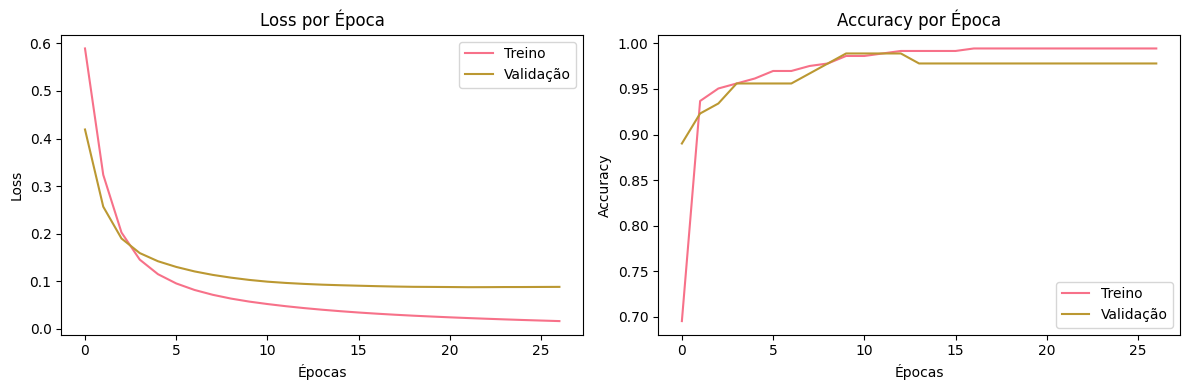

In [45]:
# Curvas de treino
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Treino')
plt.plot(history_baseline.history['val_loss'], label='Validação')
plt.title('Loss por Época')
plt.xlabel('Épocas'); plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Treino')
plt.plot(history_baseline.history['val_accuracy'], label='Validação')
plt.title('Accuracy por Época')
plt.xlabel('Épocas'); plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
